# 確率分布のグラフ

Jupyter Notebook で
様々な確率分布の確率密度関数のグラフをプロットしてみる。

## 全般の注意

この Notebook では
`matplotlib`, `numpy`, `pandas`, `scipy` といった
Python モジュールを必要とする。
Jupyter Notebook が動作する環境においてはインストール済みのはずだが，
次のセルを実行して import 可能か確認してもらいたい。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

この Notebook のセルのほとんどでは
必要なモジュールをその都度 import し，
セル単体で実行できるようにしている。
しかし話題の流れの中で，前のセルの変数を利用したり，import を省略していることがある。
セルの実行に問題が発生したときは，
この Notebook 全体を実行し直すか，
セクションの先頭から実行し直してもらいたい。

## 離散確率分布

### 二項分布

二項分布は，コイン投げ (coin toss) のような，
結果が成功失敗の 2つしかない試行（ベルヌーイ試行と呼ばれる）を
$n$ 回独立に行い，成功した回数の分布である。

Python のデータフレーム `pandas` を使うと
表形式のデータを作ることができる。
いくつかの $n$ で二項分布の表を `pandas` で作ってみる。

In [2]:
from scipy.stats import binom
import pandas as pd

n = 2
p = 1/2

xs = range(n+1)
ys = binom.pmf(xs, n, p)

pd.DataFrame({'確率': ys})

,確率
0,0.25
1,0.50
2,0.25


In [3]:
from scipy.stats import binom
import pandas as pd

n = 3
p = 1/2
xs = range(n+1)
ys = binom.pmf(xs, n, p)

pd.DataFrame({'確率': ys})

,確率
0,0.125
1,0.375
2,0.375
3,0.125


In [4]:
from scipy.stats import binom
import pandas as pd

n = 4
p = 1/2
xs = range(n+1)
ys = binom.pmf(xs, n, p)
pd.DataFrame({'確率': ys})

,確率
0,0.0625
1,0.2500
2,0.3750
3,0.2500
4,0.0625


<BarContainer object of 5 artists>

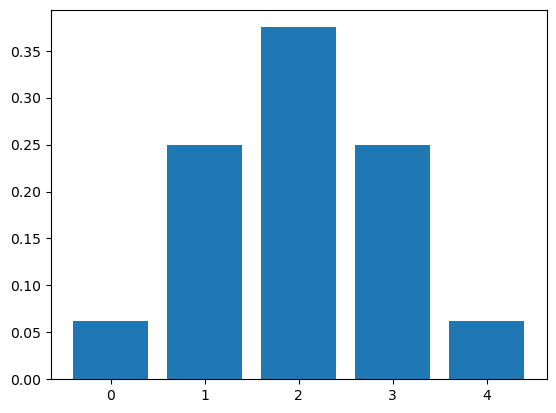

In [5]:
from scipy.stats import binom
import pandas as pd
import matplotlib.pyplot as plt

n = 4
p = 1/2
xs = range(n+1)
ys = binom.pmf(xs, n, p)
plt.bar(xs, ys)

### ポアソン分布

二項分布 $B(n, p)$ に対し

$$
\mathrm{Poi}(\mu) := \lim_{n\to\infty} B\left(n, \frac{\mu}{n}\right)
$$

で得られる確率分布をポアソン分布という。
小さい成功確率の多数のベルヌーイ試行について，成功する事象の個数の分布として観察される。

ポアソン分布の期待値は
$$
\lim_{n\to\infty} np = \frac{n\mu}{n} = \mu
$$

分散は
$$
\lim_{n\to\infty} np(1-p) = \lim_{p\to 0} \frac{\mu}{p}p(1-p) = \mu
$$

$\mu = 0.5$ のポアソン分布

In [6]:
from scipy.stats import poisson
import pandas as pd

μ = 0.5
dist = poisson(μ)
xs = range(5)
ys = dist.pmf(xs)
pd.DataFrame({'割合': ys})

,割合
0,0.606531
1,0.303265
2,0.075816
3,0.012636
4,0.001580


同じものを棒グラフで描く。
`scipy` や `pandas` は上のセルでインポートしている前提。

<BarContainer object of 5 artists>

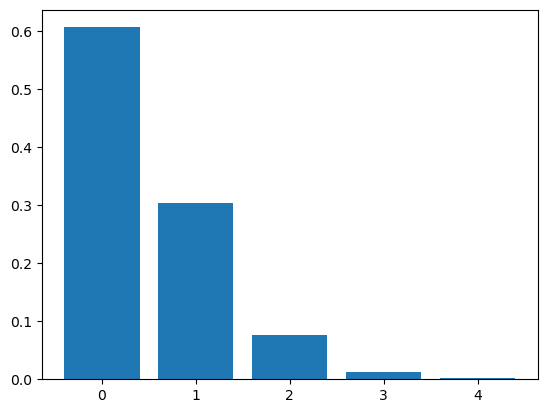

In [7]:
import matplotlib.pyplot as plt

plt.bar(xs, ys)

ヒストグラム風にしてみた。

<BarContainer object of 5 artists>

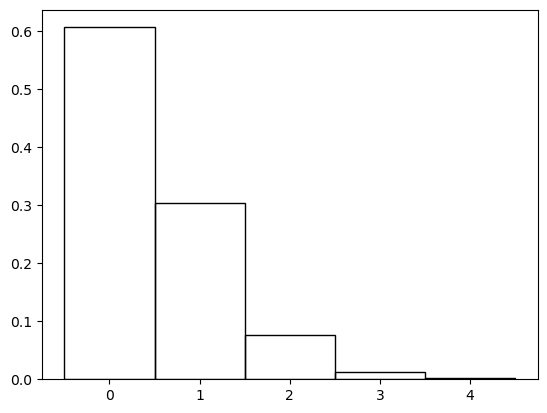

In [8]:
import matplotlib.pyplot as plt

plt.bar(xs, ys, width=1, edgecolor="black", color="none")

パラメータ &mu; の値を変えながらプロットしてみる。

<BarContainer object of 8 artists>

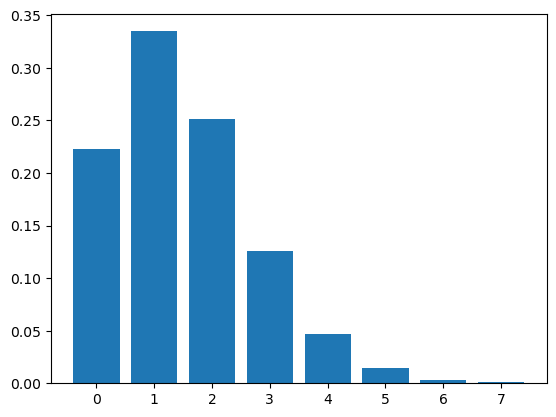

In [9]:
from scipy.stats import poisson
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt

μ = 1.5
xs = range(8)
ys = poisson.pmf(xs, μ)
plt.bar(xs, ys)

<BarContainer object of 8 artists>

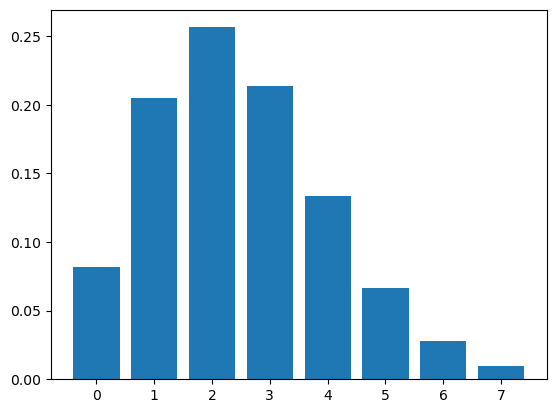

In [10]:
from scipy.stats import poisson
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt

μ = 2.5
xs = range(8)
ys = poisson.pmf(xs, μ)
plt.bar(xs, ys)

<BarContainer object of 11 artists>

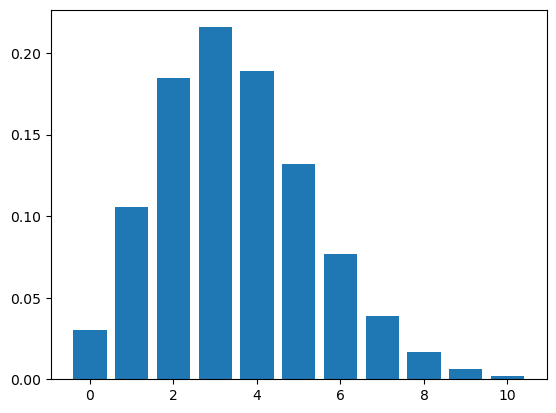

In [11]:
from scipy.stats import poisson
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt

μ = 3.5
xs = range(11)
ys = poisson.pmf(xs, μ)
plt.bar(xs, ys)

<BarContainer object of 11 artists>

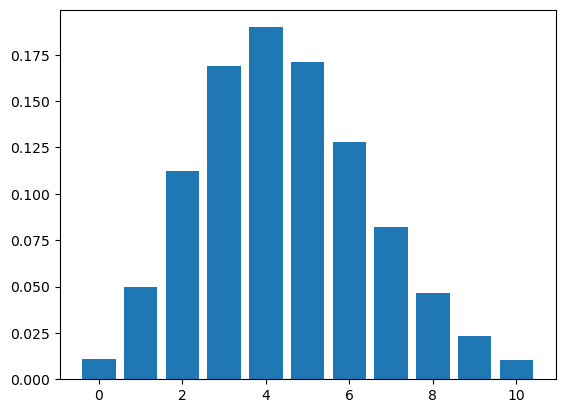

In [12]:
from scipy.stats import poisson
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt

μ = 4.5
xs = range(11)
ys = poisson.pmf(xs, μ)
plt.bar(xs, ys)

パラメータ &mu; が大きくなると正規分布に近づく

<BarContainer object of 15 artists>

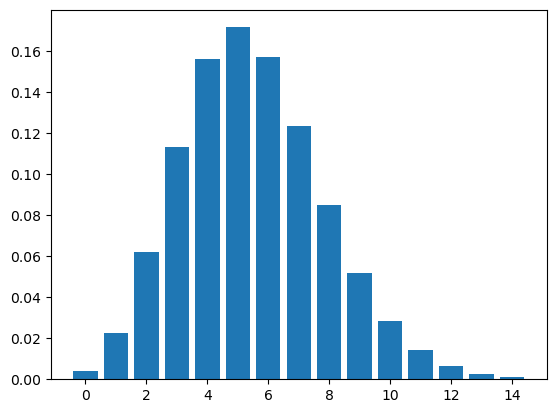

In [13]:
from scipy.stats import poisson
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt

μ = 5.5
xs = range(15)
ys = poisson.pmf(xs, μ)
plt.bar(xs, ys)

<BarContainer object of 25 artists>

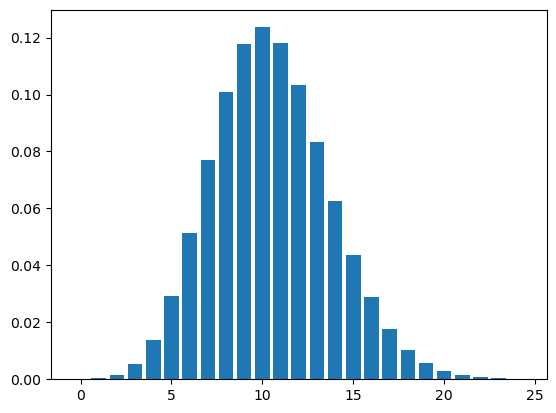

In [14]:
from scipy.stats import poisson
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt

μ = 10.5
xs = range(25)
ys = poisson.pmf(xs, μ)
plt.bar(xs, ys)

### 幾何分布

幾何分布とは，
成功確率 $p$ のベルヌーイ試行が成功するまでの回数の確率分布である。
たとえば

* コイントスで言えば，最初に表（おもて）になるまでコインを何回投げるか
* ボウリングあるいは野球の投球で言えば，確率 $p$ でストライクを取れる人が，最初にストライクをとれるまでの回数

**幾何分布**の名称は，確率質量関数が等比数列＝幾何数列，
累積分布関数が等比級数＝幾何級数になることに由来する。
確率質量関数は次のとおり
$$
\mathrm{pmf}(X) = (1-p)^{X-1} p.
$$

指数の肩の $X-1$ を $X$ にした $(1-p)^X p$ だと，
成功するまでの失敗回数になる。
この方が式が簡単になるのでテキストによってはこちらを採用している。

しかし Python の `scipy.stat.geom` は，成功するまでの試行回数
という定義を採用している。
そのため 試行回数は必ず 1以上になる。
$\therefore\; \Pr(X = 0) = 0.$

なお成功確率 $p$ は確率分布のパラメータなので，確率変数 $X$ にとっては定数である。
つまり $\mathrm{pmf}(X)$ は $X$ の冪乗関数である。
また $X$ は正の整数の値しかとらない ($X = 1, 2, 3, \ldots$) ので
等比数列である。等比数列は**幾何数列** (geometric sequence) ともいう。

In [23]:
from scipy.stats import geom
import pandas as pd

p = 0.5
dist = geom(p)
xs = range(0, 5)
ys = dist.pmf(xs)
pd.DataFrame({'確率': ys})

,確率
0,0.0000
1,0.5000
2,0.2500
3,0.1250
4,0.0625


$X=0$ の確率は 0 なので，この部分はカットしたい。
1からスタートする整数列を `pandas` のデータフレームの index とする。

In [24]:
from scipy.stats import geom
import pandas as pd

p = 0.5
dist = geom(p)
xs = range(1, 5)
ys = dist.pmf(xs)
pd.DataFrame({'確率': ys}, index = xs)

,確率
1,0.5000
2,0.2500
3,0.1250
4,0.0625


<BarContainer object of 4 artists>

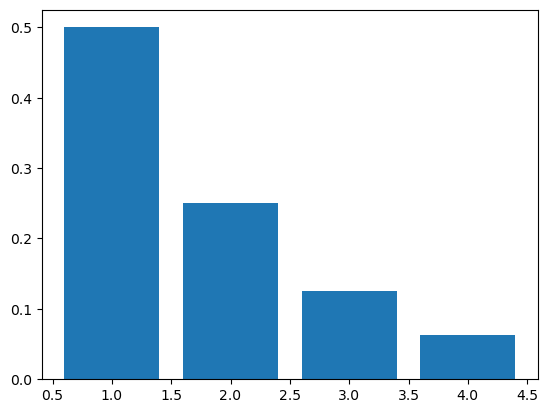

In [25]:
import matplotlib.pyplot as plt

plt.bar(xs, ys)

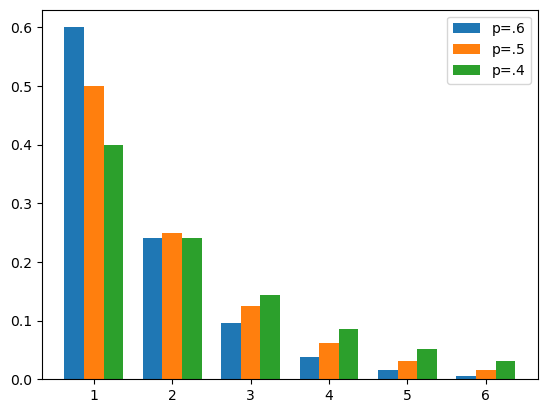

In [27]:
from scipy.stats import geom
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

xs = np.arange(1, 7)

ys6 = geom.pmf(xs, 0.6)
plt.bar(xs-0.25, ys6, width=0.25)

ys5 = geom.pmf(xs, 0.5)
plt.bar(xs, ys5, width=0.25)

ys4 = geom.pmf(xs, 0.4)
plt.bar(xs+0.25, ys4, width=0.25)

plt.legend(["p=.6", "p=.5", "p=.4"])

参考までに，幾何分布 $G(p)$ の
平均値（期待値），分散，歪度，尖度は，それぞれ次のとおり。
ただし $q = 1-p$ つまり失敗確率とする。

$$
\begin{align}
E(X) &= 1/p \\
\mathrm{Var}(X) &= \frac{1-p}{p^2} = \frac{q}{p^2} \\
\mathrm{Skew}(X) &= \sqrt{1-p} + \frac{1}{\sqrt{1-p}} = \sqrt{q} + \frac{1}{q} \\
\mathrm{Kurt}(X) &= \frac{p^2-6p+6}{1-p} - 3 = q + \frac{1}{q} + 1
\end{align}
$$

成功確率 $p$ のベルヌーイ試行を $n$ 回成功するまでに
失敗した回数の分布を負の二項分布という。

失敗回数 $X$ に対し $Y = X + 1$ とすると $Y$ は成功するまでの試行回数なので，
$n = 1$ のとき $Y$ の分布は**幾何分布**である。
つまり，幾何分布は負の二項分布の特別な例である。

負の二項分布の名称は，
確率質量関数が**負の二項係数**になることに由来する。
二項分布とはおよそ関係ないので混乱しないでもらいたい。

In [28]:
from scipy.stats import nbinom
import pandas as pd

p = 0.5
n = 3
dist = nbinom(n, p)
xs = range(10)
ys = dist.pmf(xs)
pd.DataFrame({'確率': ys})

,確率
0,0.125000
1,0.187500
2,0.187500
3,0.156250
4,0.117188
5,0.082031
6,0.054688
7,0.035156
8,0.021973
9,0.013428


<BarContainer object of 10 artists>

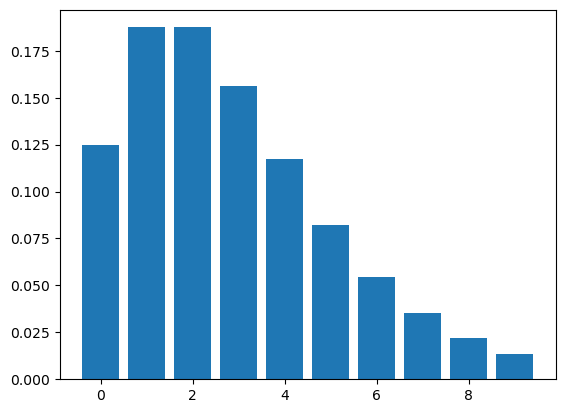

In [29]:
import matplotlib.pyplot as plt

plt.bar(xs, ys)

負の二項分布に関しては

* 何回で定着するか
* 何回で合格するか

が関心事であることが多いだろう。
これは累積分布関数で得られる。

In [30]:
ys = dist.cdf(xs)
pd.DataFrame({'確率': ys})

,確率
0,0.125000
1,0.312500
2,0.500000
3,0.656250
4,0.773438
5,0.855469
6,0.910156
7,0.945312
8,0.967285
9,0.980713


累積分布関数から次のことが読み取れる。
* $X=2$ で 50%; 失敗回数 2, 成功回数 _n_ = 3, 計試行回数5回で 50% の定着
* $X=7$ で 95%; 失敗回数 7, 成功回数 _n_ = 3, 計試行回数 10回で 95% の定着

<BarContainer object of 15 artists>

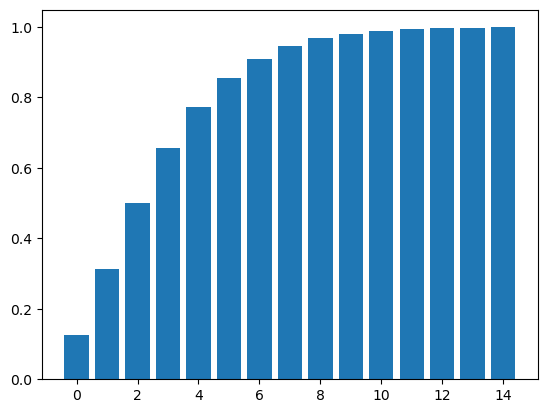

In [116]:
import matplotlib.pyplot as plt

plt.bar(xs, ys)

例題：
赤，白，黒の3種類の玉が抽選箱に入っているとき
4個取り出すときの組み合わせの数はいくらか。

解答：赤，白，黒の順になるようにソーティングして列挙する。

| 玉の組み合わせ | 仕切りの位置 |
|----------|------------|
| 赤赤赤赤 | `....++` |
| 赤赤赤白 | `...+.+` |
| 赤赤赤黒 | `...++.` |
| 赤赤白白 | `..+..+` |
| 赤赤白黒 | `..+.+.` |
| 赤赤黒黒 | `..++..` |
| 赤白白白 | `.+...+` |
| 赤白白黒 | `.+..+.` |
| 赤白黒黒 | `.+.+..` |
| 赤黒黒黒 | `.++...` |
| 白白白白 | `+....+` |
| 白白白黒 | `+...+.` |
| 白白黒黒 | `+..+..` |
| 白黒黒黒 | `+.+...` |
| 黒黒黒黒 | `++....` |

このように玉の組み合わせは 15通りある。
これは玉と仕切りを併せたもの（6個）から仕切りを2個選ぶ組合せと同じである。

$$
{}_3\mathrm{H}_4 = {}_6\mathrm{C}_2 = \frac{6!}{4!\cdot 2!} = \frac{6\cdot 5}{2} = 15
$$

一般化すると，
> $n$ 種類の玉から $k$ 個選ぶときの重複組合せ

は，玉が $k$ 個，仕切りが $n-1$ 個のとき，

> 玉と仕切りを併せたもの $k + n - 1$ 個から，仕切り $n-1$ 個を選ぶ，
> あるいは玉 $k$ 個を選ぶ組合せ

と対応する。その個数は

$$
{}_n\mathrm{H}_k = {}_{k + n - 1}\mathrm{C}_{n - 1}
$$

負の二項分布の定義まで振り返ろう。
これは $n$ 回成功するまでに $k$ 回失敗する組合せの個数に等しい。

**超幾何分布** (hypergeometric distribution)は
二項分布の非復元抽出バージョンである。

復元抽出では，抽選箱から取り出した玉は抽選箱に戻して，それから次の試行を行う。
すべての試行で成功確率は同一である。

非復元抽出では，抽選箱から取り出した玉を抽選箱に戻さずに次の試行を行う。
そのため
* 試行が成功すれば，当たりの球が減るので次の試行の成功確率が減る。
* 試行が失敗すれば，当たりの球が減らずに全体の球が減るので成功確率が高くなる。

超幾何分布は次のパラメータで定まる。

* 全体の個数 $M$
* 当たりの個数 $n$
* 試行回数 $N$

確率変数は，当たりが選ばれた個数である。

たとえばロシアンルーレットは，
全体の個数 $M=6$, 当たりの個数 $n = 1$ の超幾何分布とみなせる。
試行回数 $N=6$ とすると

確率変数 $K=0$ となる確率は

$$
\frac{5}{6}\cdot\frac{4}{5}
           \cdot\frac{3}{4}
           \cdot\frac{2}{3}
           \cdot\frac{1}{2}
           \cdot\frac{0}{1} = 0
$$

である。 $K=1$ となる確率は

$$
\frac{1}{6}+\frac{5}{6}\cdot\frac{1}{5}
           +\frac{5}{6}\cdot\frac{4}{5}\cdot\frac{1}{4}
           +\cdots
           +\frac{5}{6}\cdots\frac{1}{2}\cdot\frac{1}{1}
           = 1
$$

In [137]:
from scipy.stats import hypergeom
import pandas as pd

trials = 6
dist = hypergeom(6, 1, trials)
xs = range(2)
ys = dist.pmf(xs)
pd.DataFrame({'割合': ys})

,割合
0,0.0
1,1.0


このように，事象ごとに確率を計算すると，
試行するごとに玉の数が減り，
分母が ${}_n\mathrm{P}_r$ で表される式になる。
この式が**超幾何数列**と呼ばれるものに分類されることから，
この確率分布は**超幾何分布**と呼ばれている。
幾何分布とは名前が似ていても関係ない。

超幾何数列の定義に踏み込むと大変なので，基本イメージを紹介する。
無限級数とかテーラー展開を知っていることが前提である。

三角関数，指数関数を無限級数展開すると係数の分母に階乗が現れる。
他の関数でも，しばしば係数の分母，分子に，階乗や階乗を拡張したような式が現れる。
このような級数を，（等比級数＝幾何級数よりも複雑だという意味で）超幾何級数と
名前を付けて分類した。
数学の公式集があれば，無限級数展開の係数を眺めてもらいたい。
多くは超幾何級数である。

超幾何級数を微分しても超幾何級数になることから，
微分方程式の解法として研究された。

$$
\mathrm{pmf}(K) = \frac{({}_n\mathrm{C}_K)({}_{M-n}\mathrm{C}_{N-K})}
                       {{}_M\mathrm{C}_N}
$$

## 連続確率分布

### 正規分布

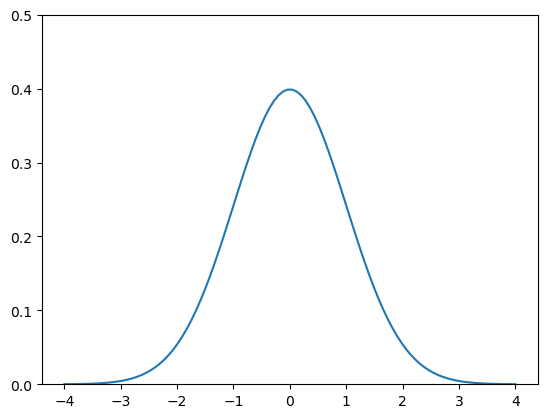

In [33]:
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

xs = np.linspace(-4, 4, 100)    # [-4.0, -3.92, ..., 3.92, 4.0]
ys = norm.pdf(xs)
plt.ylim(0, 0.5)
plt.plot(xs, ys)

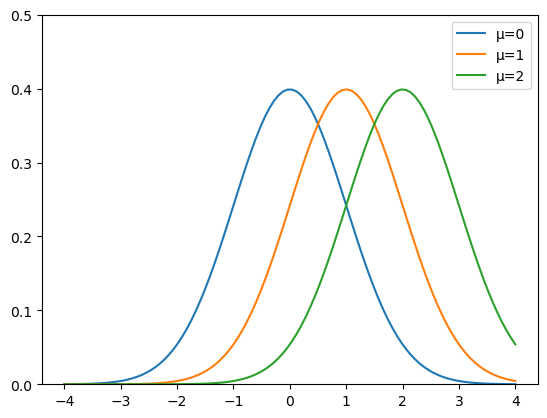

In [14]:
xs = np.linspace(-4, 4, 100)
ys0 = norm.pdf(xs)
plt.ylim(0, .5)
plt.plot(xs, ys0, label = "μ=0")

ys1 = norm.pdf(xs, loc=1)
plt.plot(xs, ys1, label = "μ=1")

ys2 = norm.pdf(xs, loc=2)
plt.plot(xs, ys2, label = "μ=2")

plt.legend()

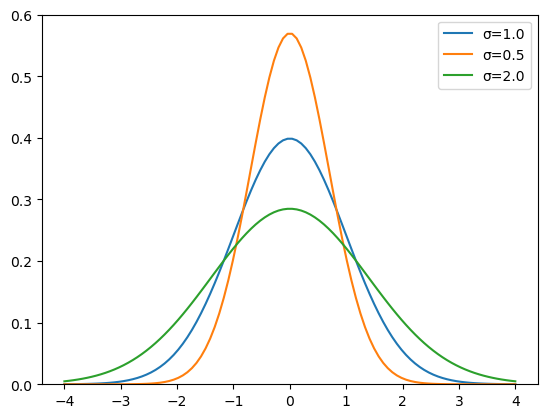

In [18]:
xs = np.linspace(-4, 4, 100)
ys0 = norm.pdf(xs)
plt.ylim(0, .6)
plt.plot(xs, ys0, label = "σ=1.0")

ys1 = norm.pdf(xs, scale = 0.7)
plt.plot(xs, ys1, label = "σ=0.7")

ys2 = norm.pdf(xs, scale = 1.4)
plt.plot(xs, ys2, label = "σ=1.4")

plt.legend()

### カイ2乗分布

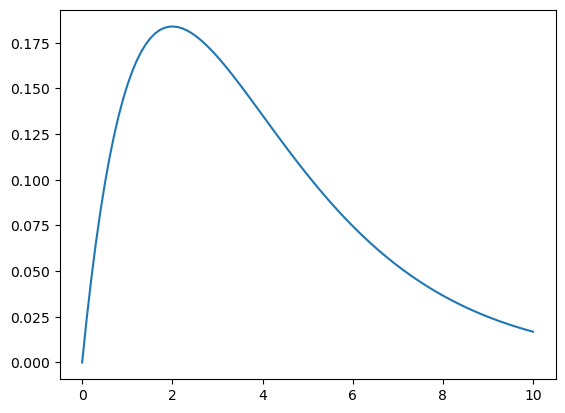

In [129]:
from scipy.stats import chi2
import numpy as np
import matplotlib.pyplot as plt

xs = np.linspace(0, 10, 100)
ys = chi2.pdf(xs, df=4)   # df: degree of freedom
# plt.ylim(0, 0.5)
plt.plot(xs, ys)

### t分布

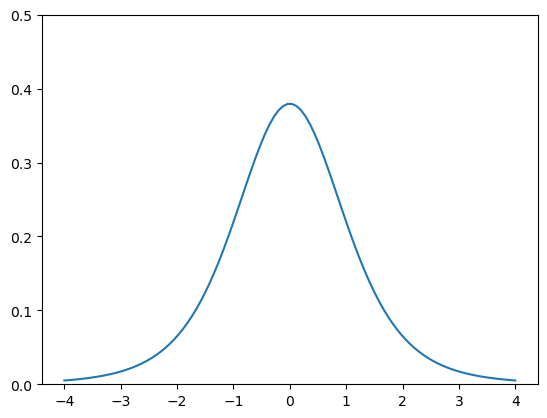

In [32]:
from scipy.stats import t
import numpy as np
import matplotlib.pyplot as plt

xs = np.linspace(-4, 4, 100)
ys = t.pdf(xs, df=5)   # df: degree of freedom
plt.ylim(0, 0.5)
plt.plot(xs, ys)

## 一様分布と乱数

### 一様分布と一様乱数

### 離散一様分布の和

### 三角分布

### 正規乱数